<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Examples.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

In [2]:
dataset = pd.read_csv("https://raw.githubusercontent.com/Kalungup/Income-Based-Purchase-Prediction-Model/refs/heads/main/customer_spending_dataset.csv")
dataset

,customer_id,age,income,spending_score,savings,height_cm,weight_kg,gender,city,education,date,purchase_amount
0,1,56,25287,18,31314,167,80,Female,New York,PhD,2023-01-01,2519
1,2,46,54387,40,3643,152,109,Female,Stockholm,Master,2023-01-02,22915
2,3,32,28512,21,41785,177,83,Male,London,Bachelor,2023-01-03,19997
3,4,60,21342,15,19681,155,105,Male,Stockholm,Master,2023-01-04,10001
4,5,25,83076,97,39328,193,64,Male,Nairobi,Master,2023-01-05,36005
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,22,37778,70,19156,192,84,Male,Stockholm,High School,2025-09-22,12338
996,997,40,65241,44,21360,151,81,Male,London,High School,2025-09-23,32896
997,998,27,62229,73,19135,198,107,Female,London,Bachelor,2025-09-24,26035
998,999,61,106652,45,26351,158,97,Male,London,PhD,2025-09-25,35371


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      1000 non-null   int64 
 1   age              1000 non-null   int64 
 2   income           1000 non-null   int64 
 3   spending_score   1000 non-null   int64 
 4   savings          1000 non-null   int64 
 5   height_cm        1000 non-null   int64 
 6   weight_kg        1000 non-null   int64 
 7   gender           1000 non-null   object
 8   city             1000 non-null   object
 9   education        1000 non-null   object
 10  date             1000 non-null   object
 11  purchase_amount  1000 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 93.9+ KB


In [4]:
dataset.describe()

,customer_id,age,income,spending_score,savings,height_cm,weight_kg,purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,500.500000,40.986000,69404.683000,48.108000,24048.647000,174.7780,80.217000,25517.706000
std,288.819436,13.497852,28581.018123,28.981861,14031.448907,14.7003,17.198014,10101.239778
min,1.000000,18.000000,20060.000000,1.000000,1097.000000,150.0000,50.000000,-2409.000000
25%,250.750000,29.000000,45519.000000,22.000000,11997.250000,162.0000,66.000000,18112.750000
50%,500.500000,42.000000,68816.000000,46.500000,23053.000000,175.0000,80.000000,25978.500000
75%,750.250000,52.000000,94672.250000,73.000000,35613.000000,188.0000,95.000000,33130.000000
max,1000.000000,64.000000,119986.000000,99.000000,49980.000000,199.0000,109.000000,55215.000000


#### Notes there are negative earnings, Which is not realistic, so we use absolute values instead.

In [5]:
dataset['purchase_amount'] = abs(dataset['purchase_amount'])
dataset.describe()

,customer_id,age,income,spending_score,savings,height_cm,weight_kg,purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,500.500000,40.986000,69404.683000,48.108000,24048.647000,174.7780,80.217000,25524.640000
std,288.819436,13.497852,28581.018123,28.981861,14031.448907,14.7003,17.198014,10083.687973
min,1.000000,18.000000,20060.000000,1.000000,1097.000000,150.0000,50.000000,840.000000
25%,250.750000,29.000000,45519.000000,22.000000,11997.250000,162.0000,66.000000,18112.750000
50%,500.500000,42.000000,68816.000000,46.500000,23053.000000,175.0000,80.000000,25978.500000
75%,750.250000,52.000000,94672.250000,73.000000,35613.000000,188.0000,95.000000,33130.000000
max,1000.000000,64.000000,119986.000000,99.000000,49980.000000,199.0000,109.000000,55215.000000


Let us consider the age and purchase amount

In [6]:
x = dataset[['age']]
y = dataset['purchase_amount']

<Axes: xlabel='age', ylabel='purchase_amount'>

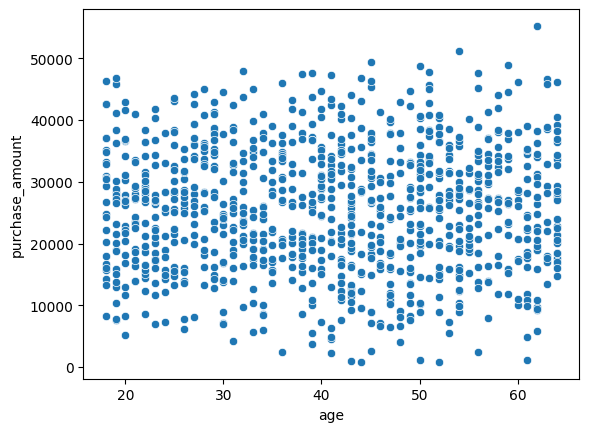

In [7]:
sns.scatterplot(x='age', y='purchase_amount', data=dataset) 

### Linearity Assessment: Age vs Purchase Amount

A scatter plot was used to examine the relationship between age and purchase_amount. The distribution of data points shows a random pattern with no clear linear trend, as the points are widely dispersed across the plot.

There is no evident upward or downward direction, indicating that changes in age do not systematically correspond to changes in purchase_amount. This suggests that the assumption of linearity is not satisfied.

Therefore, age is not an appropriate predictor of purchase_amount in a simple linear regression model, and alternative variables should be considered.

### Linearity Assessment: Income vs Purchase Amount

<Axes: xlabel='income', ylabel='purchase_amount'>

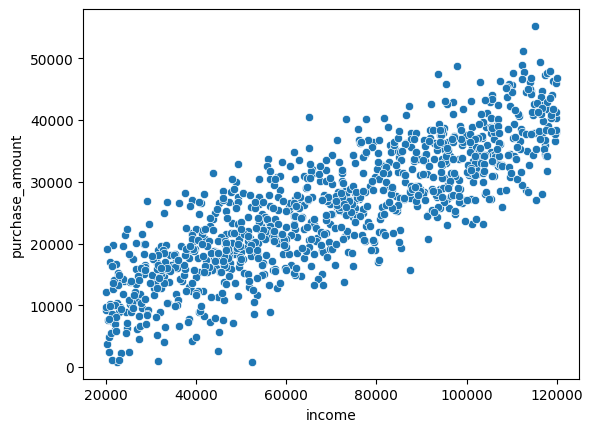

In [8]:
x = dataset[['income' ]]
y = dataset['purchase_amount']
sns.scatterplot(x='income', y='purchase_amount', data=dataset)

### Linearity Assessment: Income vs Purchase Amount

A scatter plot indicates a clear positive linear relationship between income and purchase_amount. As income increases, purchase_amount also increases.

Despite some variability, the overall upward trend is consistent, suggesting that the linearity assumption is satisfied. Therefore, income is a suitable predictor for simple linear regression.

#### Now that it meets the linearity assumption, let us check whether there are serious outliers

<Axes: xlabel='purchase_amount'>

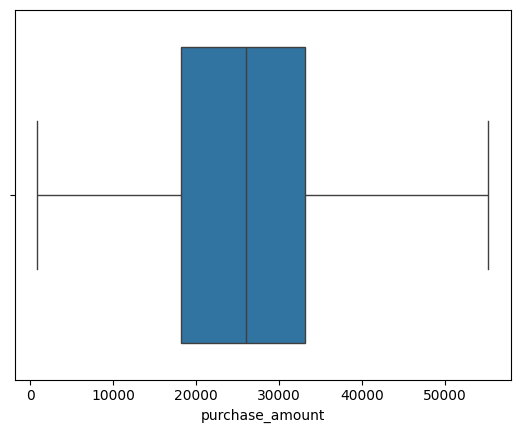

In [9]:
sns.boxplot(x='purchase_amount', data=dataset)



A boxplot was used to assess the presence of outliers in purchase_amount. The distribution appears fairly symmetrical, with no extreme values lying far beyond the whiskers.

Therefore, outliers are unlikely to have a substantial impact on the regression model.

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train, y_train)    

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = lm.predict(x_test)

### Model

Coefficient: [0.29915605]
Intercept: 4737.712634506748


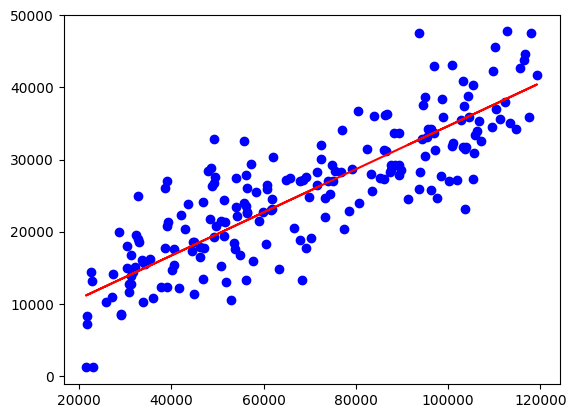

In [13]:
print("Coefficient:", lm.coef_)
print("Intercept:", lm.intercept_)
plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.plot(x_test, y_pred, color='red', label='Predicted')    

#### Sample Predction

In [18]:
income_value = int(input("Enter income to predict purchase amount: "))
predictions = lm.predict(pd.DataFrame({'income': [income_value]}))
print (f"For a customer whose income is {income_value}, the predicted purchase amount is: {predictions[0]}")


For a customer whose income is 10000, the predicted purchase amount is: 7729.273156645439


## Regression Results Interpretation

The estimated coefficient for income is approximately 0.30, indicating that for each additional unit increase in income, the purchase amount increases by about 0.30 units. The intercept of approximately 4738 represents the baseline predicted purchase amount when income is zero.

The scatter plot with the fitted regression line shows a clear positive linear relationship between income and purchase amount. The data points are reasonably close to the regression line, suggesting that the model captures the general trend in the data.

However, some dispersion around the line is observed, indicating the presence of prediction errors. Overall, the model provides a good fit, though variability in the data suggests that additional variables could further improve predictive accuracy.

### Model Evaluation

#### Residuals

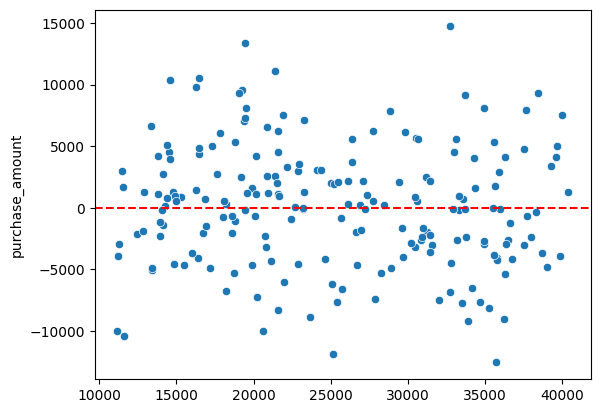

In [ ]:
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')

## Residual Plot Interpretation

The residual plot presents the differences between actual and predicted values against the predicted values. Residuals represent the model's prediction errors.

The residuals are randomly distributed around zero, indicating that the model does not exhibit systematic bias and that the linear relationship is appropriate.

However, the relatively wide dispersion of residuals suggests moderate prediction error. This indicates that while the model captures the overall trend, its predictive precision is limited.


#### R_score, MSE, RMSE

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", np.sqrt(mse))

Mean Squared Error: 24705526.35957428
R-squared: 0.7110668005163702
Mean Absolute Error: 3934.37835256562
Root Mean Squared Error: 4970.46540673751


### Model Suitability Assessment

- **R² = 0.71**  
  - Explains **71% of the variance** in purchase amount  
  - 🟢 **Good fit** — model captures the overall relationship well  

- **MAE ≈ 3,934 SEK**  
  - Average prediction error is about **3,934 SEK**  
  - 🟡 **Moderate error** — acceptable but not highly precise  

- **RMSE ≈ 4,970 SEK**  
  - Typical prediction error is around **5,000 SEK**  
  - 🟡 **Moderate error**, slightly higher than MAE → indicates some larger errors  

- **MSE ≈ 24,705,526**  
  - Reflects squared error magnitude  
  - 🟡 Less interpretable, but consistent with RMSE  

---

### Overall Conclusion

- The model is **🟢 suitable and reasonably accurate** for predicting purchase amount using income  
- However, the **🟡 moderate error levels** indicate that predictions are not highly precise  
- The model can be **improved by including additional variables** (e.g., age, spending score, savings)